# Diabetes Prediction Using Machine Learning and Deep Learning

---

## Student Information

**Student Name:** Loic Higiro

**Course:** Introduction to Machine Learning

**Assignment:** Summative Assignment – Model Training and Evaluation

**Date:** June 2026

---

# 1. Project Description

## Background

Diabetes is a chronic disease that affects millions of people worldwide and remains one of the leading causes of serious health complications such as cardiovascular disease, kidney failure, blindness, and premature death. Early diagnosis and intervention can significantly improve patient outcomes and reduce healthcare costs.

Advances in Machine Learning (ML) and Deep Learning (DL) have created opportunities to support healthcare professionals by developing predictive systems capable of identifying patients at risk of diabetes based on clinical and demographic information.

This project investigates the effectiveness of both traditional machine learning algorithms and deep learning models in predicting diabetes using healthcare data.

---

# 2. Problem Statement

Accurate and timely diagnosis of diabetes is critical for preventing severe complications and improving patient care. However, traditional diagnostic procedures can be time-consuming and may require extensive laboratory testing.

The problem addressed in this project is:

> Can machine learning and deep learning models accurately predict whether a patient has diabetes using available clinical and demographic features?

To answer this question, multiple machine learning and deep learning models will be developed, trained, optimized, and evaluated.

---

# 3. Project Objectives

The objectives of this project are:

1. To understand and explore the diabetes dataset through Exploratory Data Analysis (EDA).
2. To preprocess healthcare data and prepare it for machine learning applications.
3. To implement traditional machine learning algorithms using Scikit-learn.
4. To implement deep learning models using TensorFlow.
5. To perform multiple experiments with different hyperparameter settings.
6. To evaluate and compare model performance using appropriate metrics.
7. To identify the most effective approach for diabetes prediction.

---

# 4. Dataset Description

## Dataset Overview

This project uses a Diabetes Prediction Dataset containing demographic and clinical information collected from patients.

The dataset contains several predictor variables, including:

- Gender
- Age
- Hypertension
- Heart Disease
- Smoking History
- Body Mass Index (BMI)
- HbA1c Level
- Blood Glucose Level

### Target Variable

**Diabetes**

- 0 = No Diabetes
- 1 = Diabetes

The target variable indicates whether the patient has diabetes.

---

# 5. Research Questions

This project seeks to answer the following questions:

1. Which machine learning algorithm performs best for diabetes prediction?
2. Do deep learning models outperform traditional machine learning methods?
3. Which features contribute most significantly to diabetes prediction?
4. How do different hyperparameter configurations affect performance?
5. What limitations exist within the dataset and predictive models?

---

# 6. Methodology Overview

The project will follow the workflow below:

1. Data Collection
2. Exploratory Data Analysis (EDA)
3. Data Cleaning and Preprocessing
4. Feature Engineering
5. Machine Learning Model Development
6. Deep Learning Model Development
7. Model Evaluation
8. Experimental Comparison
9. Error Analysis
10. Conclusion and Future Work

---

# 7. Expected Outcomes

The expected outcome of this project is the development of a reliable predictive model capable of identifying individuals at risk of diabetes. The project will also compare the effectiveness of traditional machine learning techniques and deep learning approaches while providing insights into their strengths and limitations.

---

# Notebook Structure

The notebook is organized into the following sections:

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Machine Learning Experiments
7. Deep Learning Experiments
8. Model Evaluation
9. Results and Discussion
10. Conclusion

# Step 1: Import Libraries

## Purpose

Before beginning the machine learning workflow, it is necessary to import the required Python libraries. These libraries provide functionality for data manipulation, visualization, machine learning model development, and deep learning implementation.

The libraries used in this project serve the following purposes:

- **NumPy** for numerical computations and array operations.
- **Pandas** for data loading, cleaning, and manipulation.
- **Matplotlib** and **Seaborn** for data visualization.
- **Scikit-learn** for machine learning algorithms, preprocessing, and evaluation metrics.
- **TensorFlow/Keras** for deep learning model development.
- **Warnings** to suppress unnecessary warning messages and improve notebook readability.

Setting a random seed ensures that experiments are reproducible and produce consistent results across multiple executions.

### Expected Outcome

After executing the code in this section, all required libraries will be loaded successfully and the notebook environment will be ready for data analysis and model development.

In [1]:
# ==========================================================
# Step 1: Import Required Libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2: Data Loading

## Purpose

Before performing any analysis or model development, the dataset must be loaded into the notebook environment. This step verifies that the dataset can be accessed successfully and provides an initial overview of its structure.

The dataset used in this project contains demographic and clinical information that will be used to predict whether a patient has diabetes.

At this stage, we will:

- Load the dataset into a Pandas DataFrame.
- Verify the number of rows and columns.
- Display the first few records.
- Confirm that the dataset has been imported correctly.

### Expected Outcome

After completing this step, the dataset will be available for exploration and preprocessing.

In [2]:

# Step 2: Load Dataset
import pandas as pd

# Load dataset
df = pd.read_csv("diabetes_dataset.csv")

# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (100000, 16)


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [3]:
# Display Column Names

print("Columns in Dataset:")
print(df.columns.tolist())

Columns in Dataset:
['year', 'gender', 'age', 'location', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']


In [4]:
# Basic Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  float64
 3   location              100000 non-null  str    
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  str    
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  diabetes    

In [5]:
# Statistical Summary
df.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (100000, 16)


In [7]:
df.columns.tolist()

['year',
 'gender',
 'age',
 'location',
 'race:AfricanAmerican',
 'race:Asian',
 'race:Caucasian',
 'race:Hispanic',
 'race:Other',
 'hypertension',
 'heart_disease',
 'smoking_history',
 'bmi',
 'hbA1c_level',
 'blood_glucose_level',
 'diabetes']

# Step 3: Exploratory Data Analysis (EDA)

## Purpose

Exploratory Data Analysis (EDA) is performed to better understand the structure, characteristics, and quality of the dataset before applying machine learning techniques.

This stage helps identify:

- Missing values
- Data distributions
- Class imbalance
- Potential outliers
- Relationships between variables
- Patterns associated with diabetes

Understanding these characteristics is essential for selecting appropriate preprocessing techniques and modeling approaches.

### Expected Outcome

By the end of this section, we will have a clear understanding of the dataset and any challenges that must be addressed before model training.

In [8]:
# Missing Values Analysis
print("Missing Values Per Column")
print(df.isnull().sum())

Missing Values Per Column
year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64


In [9]:
# Dataset Overview
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

df.head()

Number of Rows: 100000
Number of Columns: 16


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [10]:
# Diabetes Class Distribution
print(df['diabetes'].value_counts())

print("\nPercentage Distribution")

print(
    df['diabetes']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

diabetes
0    91500
1     8500
Name: count, dtype: int64

Percentage Distribution
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


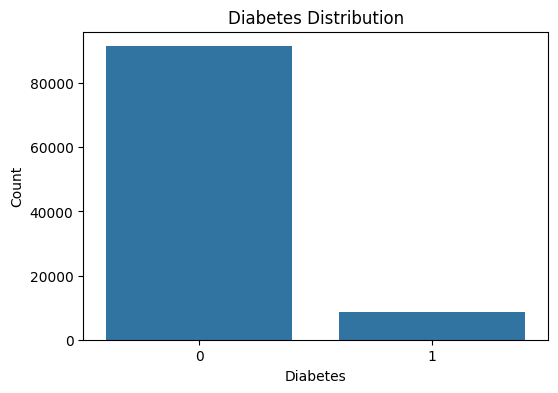

In [11]:
# Diabetes Distribution Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='diabetes'
)

plt.title('Diabetes Distribution')
plt.xlabel('Diabetes')
plt.ylabel('Count')

plt.show()

In [12]:
# Numerical Feature Statistics

numerical_columns = [
    'age',
    'bmi',
    'hbA1c_level',
    'blood_glucose_level'
]

df[numerical_columns].describe()

,age,bmi,hbA1c_level,blood_glucose_level
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,27.320767,5.527507,138.058060
std,22.516840,6.636783,1.070672,40.708136
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.630000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,60.000000,29.580000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


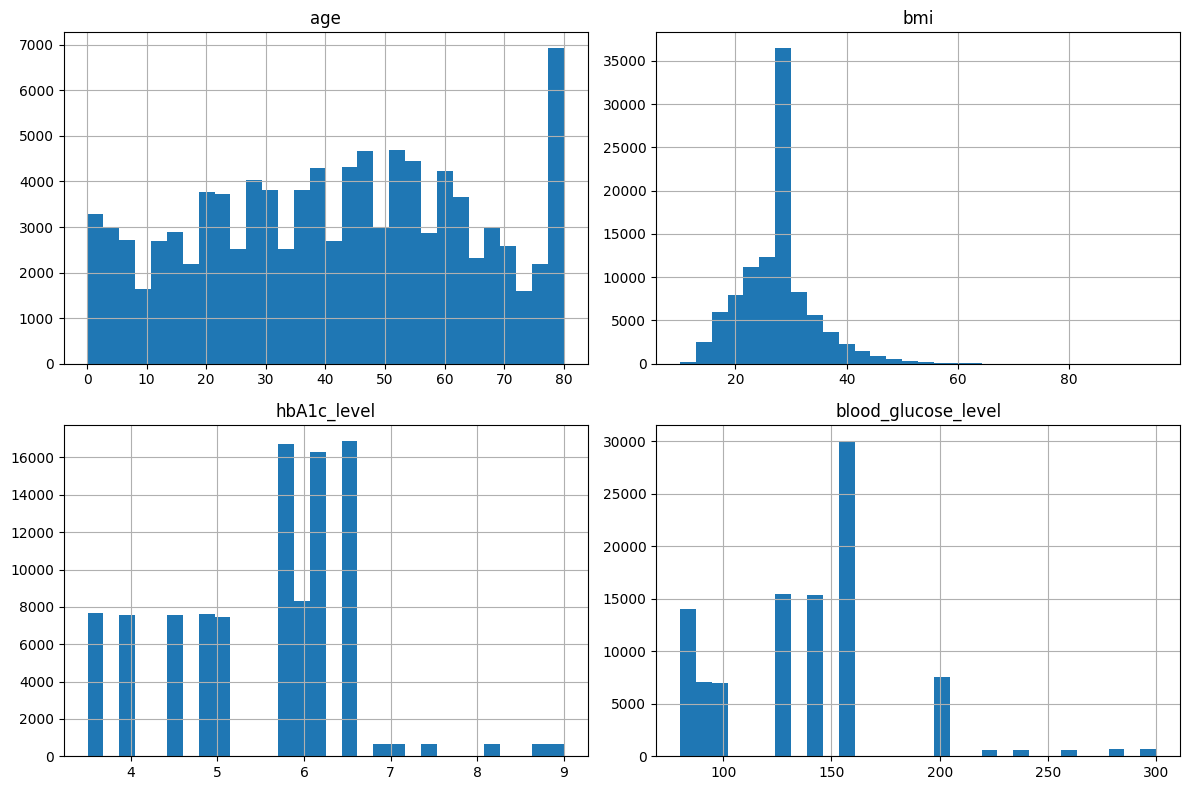

In [13]:
# Feature Distributions

df[numerical_columns].hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

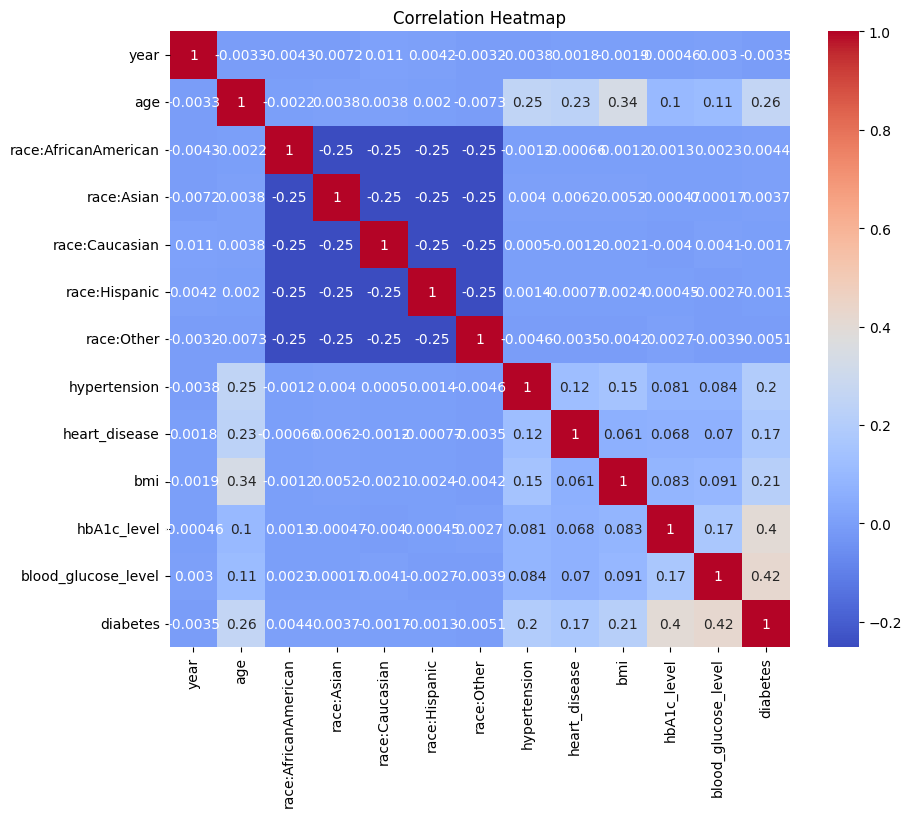

In [14]:
# Correlation Analysis

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

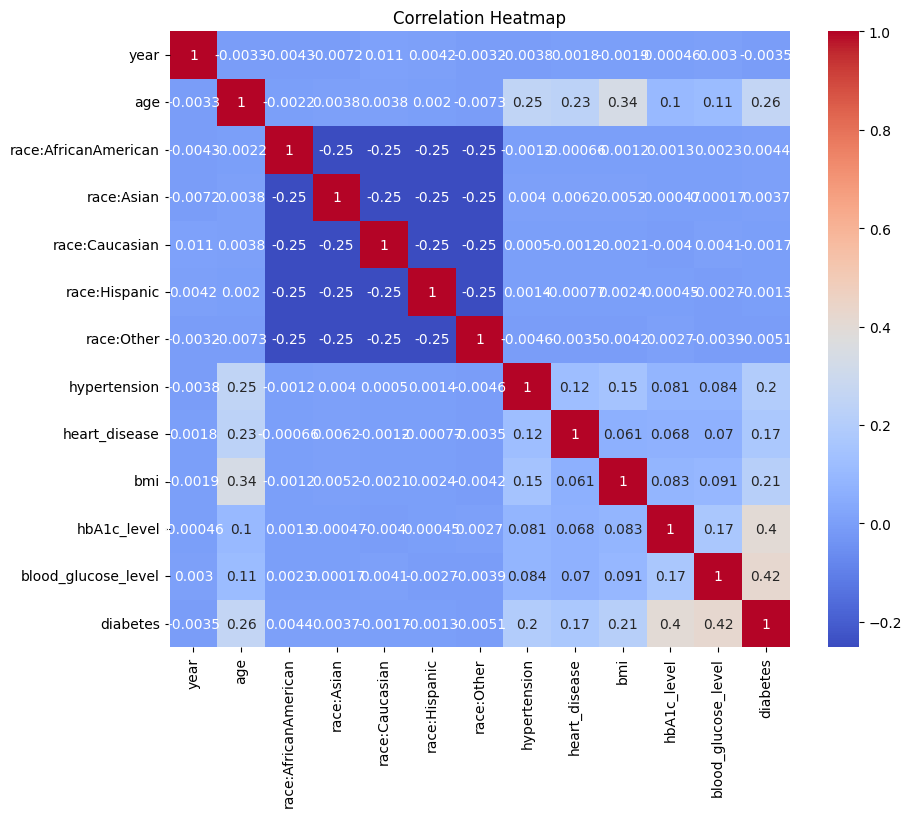

In [15]:
# Correlation Analysis

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

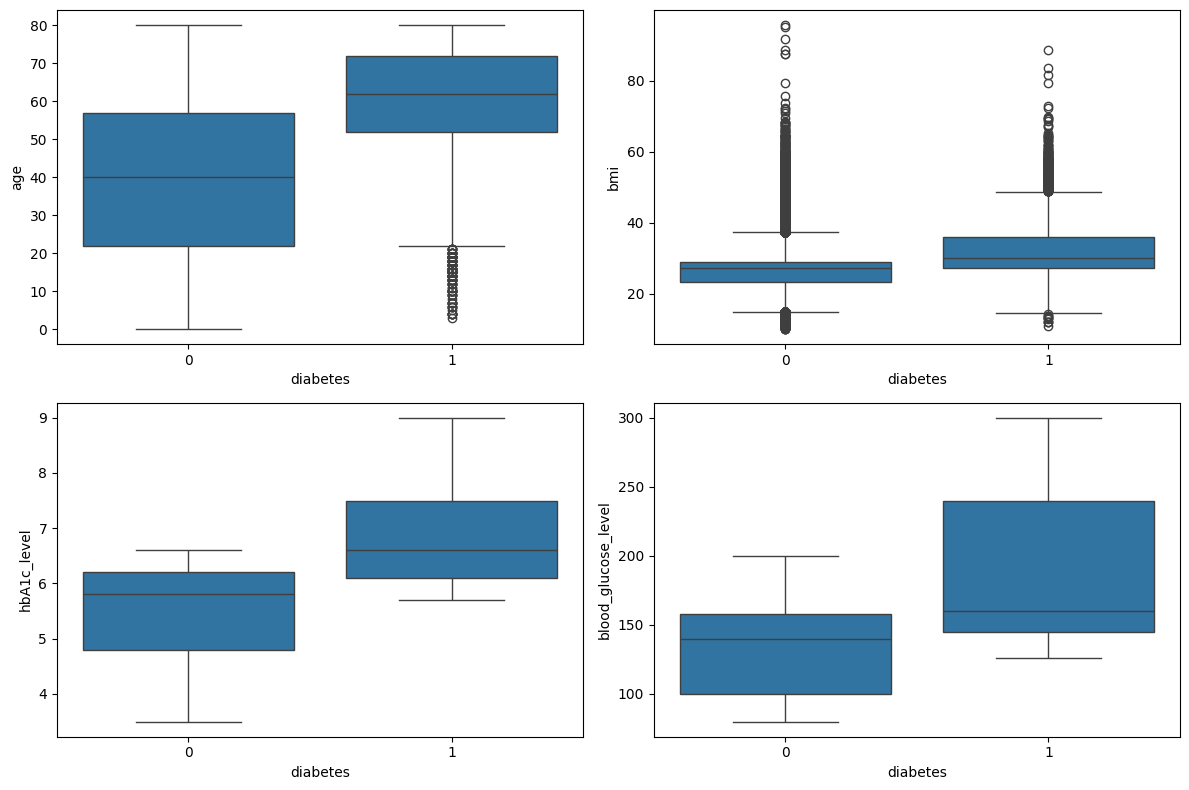

In [16]:

# Diabetes Relationship Analysis

fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.boxplot(data=df, x='diabetes', y='age', ax=axes[0,0])

sns.boxplot(data=df, x='diabetes', y='bmi', ax=axes[0,1])

sns.boxplot(data=df, x='diabetes', y='hbA1c_level', ax=axes[1,0])

sns.boxplot(data=df, x='diabetes', y='blood_glucose_level', ax=axes[1,1])

plt.tight_layout()
plt.show()

In [17]:
df['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

In [18]:
df.isnull().sum()

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

# Step 4: Data Preprocessing and Feature Engineering

## Purpose

Raw data often contains categorical variables and features with different scales that are not directly suitable for machine learning algorithms.

This stage prepares the dataset for model training by:

- Encoding categorical variables.
- Separating features and target variables.
- Splitting the dataset into training and testing sets.
- Scaling numerical features.
- Preparing data for both machine learning and deep learning models.

### Expected Outcome

At the end of this stage, the dataset will be transformed into a format suitable for predictive modeling while preserving important information contained in the original data.

In [19]:
# Identify Categorical Features
print(df.dtypes)

year                      int64
gender                      str
age                     float64
location                    str
race:AfricanAmerican      int64
race:Asian                int64
race:Caucasian            int64
race:Hispanic             int64
race:Other                int64
hypertension              int64
heart_disease             int64
smoking_history             str
bmi                     float64
hbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
dtype: object


In [20]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

df_processed = df.copy()

label_encoder = LabelEncoder()

df_processed['gender'] = label_encoder.fit_transform(df_processed['gender'])

df_processed['location'] = label_encoder.fit_transform(df_processed['location'])

df_processed['smoking_history'] = label_encoder.fit_transform(df_processed['smoking_history'])

df_processed.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,0,32.0,0,0,0,0,0,1,0,0,4,27.32,5.0,100,0
1,2015,0,29.0,0,0,1,0,0,0,0,0,4,19.95,5.0,90,0
2,2015,1,18.0,0,0,0,0,0,1,0,0,4,23.76,4.8,160,0
3,2015,1,41.0,0,0,0,1,0,0,0,0,4,27.32,4.0,159,0
4,2016,0,52.0,0,1,0,0,0,0,0,0,4,23.75,6.5,90,0


In [21]:
# Feature Selection

X = df_processed.drop('diabetes', axis=1)

y = df_processed['diabetes']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (100000, 15)
Target Shape: (100000,)


In [22]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (80000, 15)
Testing Set: (20000, 15)


In [23]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully")

Scaling Completed Successfully


In [24]:
# ==========================================================
# Final Data Check
# ==========================================================

print("Training Features:", X_train_scaled.shape)
print("Testing Features:", X_test_scaled.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (80000, 15)
Testing Features: (20000, 15)
Training Labels: (80000,)
Testing Labels: (20000,)


In [25]:
print(X_train.shape)
print(X_test.shape)

(80000, 15)
(20000, 15)


# Step 5: Machine Learning Experiment 1 - Logistic Regression

## Purpose

Logistic Regression is selected as the baseline model because it is one of the most widely used algorithms for binary classification problems.

Although relatively simple compared to advanced machine learning and deep learning models, Logistic Regression provides a strong benchmark against which more complex approaches can be compared.

The model estimates the probability that a patient belongs to the diabetic class based on the input features.

### Expected Outcome

This experiment will establish baseline performance metrics that will be compared with subsequent machine learning and deep learning experiments.

### Experiment 1 — Logistic Regression (Baseline)

In [26]:
# ==========================================================
# Experiment 1: Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


In [28]:
# Generate Predictions

y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [29]:
# ==========================================================
# Logistic Regression Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC AUC  :", round(auc,4))

Accuracy : 0.9608
Precision: 0.87
Recall   : 0.6335
F1 Score : 0.7332
ROC AUC  : 0.9612


In [30]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.87      0.63      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



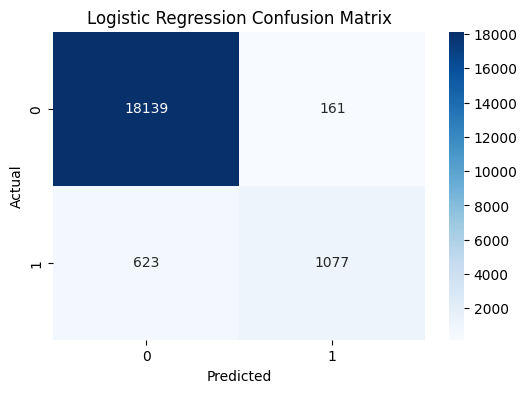

In [31]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

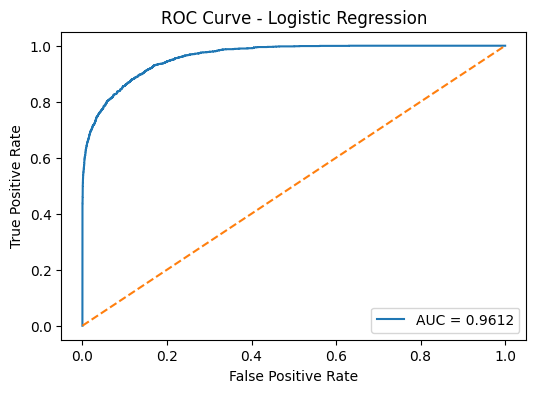

In [32]:
# ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()

plt.show()

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC AUC  :", round(auc,4))

Accuracy : 0.9608
Precision: 0.87
Recall   : 0.6335
F1 Score : 0.7332
ROC AUC  : 0.9612


### Experiment 1 Discussion

The Logistic Regression model achieved an accuracy of 96.08%, indicating strong overall predictive performance. The model also achieved a high precision score of 87.00%, meaning that when the model predicted diabetes, it was correct most of the time.

However, the recall score was lower at 63.35%, indicating that the model failed to identify a significant portion of diabetic patients. This result is likely influenced by the class imbalance present in the dataset, where only 8.5% of observations belong to the diabetic class.

The F1-score of 73.32% demonstrates a reasonable balance between precision and recall. Furthermore, the ROC-AUC score of 96.12% suggests excellent discrimination capability between diabetic and non-diabetic patients.

Overall, Logistic Regression provides a strong baseline model; however, there is room for improvement, particularly in increasing recall to better identify diabetic patients.

In [35]:
experiment_results = pd.DataFrame({
    "Experiment": ["Logistic Regression"],
    "Accuracy": [0.9608],
    "Precision": [0.8700],
    "Recall": [0.6335],
    "F1_Score": [0.7332],
    "ROC_AUC": [0.9612]
})

experiment_results

,Experiment,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.9608,0.87,0.6335,0.7332,0.9612


### Experiment 2 — Random Forest

# Step 6: Machine Learning Experiment 2 - Random Forest

## Purpose

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Compared to Logistic Regression, Random Forest can capture complex nonlinear relationships and interactions between features, making it particularly suitable for healthcare prediction tasks.

This experiment evaluates whether ensemble learning can improve diabetes prediction performance.

In [36]:
# ==========================================================
# Experiment 2: Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest Training Complete")

Random Forest Training Complete


In [37]:
# ==========================================================
# Predictions
# ==========================================================

y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(
    X_test_scaled
)[:,1]

In [38]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", round(accuracy_rf,4))
print("Precision:", round(precision_rf,4))
print("Recall   :", round(recall_rf,4))
print("F1 Score :", round(f1_rf,4))
print("ROC AUC  :", round(auc_rf,4))

Accuracy : 0.9723
Precision: 1.0
Recall   : 0.6741
F1 Score : 0.8053
ROC AUC  : 0.9686


### Experiment 2 Discussion

The Random Forest model outperformed Logistic Regression across all evaluation metrics. The model achieved an accuracy of 97.23% and a perfect precision score of 100%, indicating that every patient predicted as diabetic was correctly classified.

The recall score improved from 63.35% to 67.41%, demonstrating a better ability to identify diabetic patients. Consequently, the F1-score increased significantly to 80.53%, reflecting a stronger balance between precision and recall.

The ROC-AUC score of 96.86% further confirms the model's strong ability to distinguish between diabetic and non-diabetic patients.

These results suggest that Random Forest successfully captures nonlinear relationships and interactions among features that Logistic Regression cannot model effectively.

In [39]:
experiment_results = pd.DataFrame({
    "Experiment": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.9608,
        0.9723
    ],
    "Precision": [
        0.8700,
        1.0000
    ],
    "Recall": [
        0.6335,
        0.6741
    ],
    "F1_Score": [
        0.7332,
        0.8053
    ],
    "ROC_AUC": [
        0.9612,
        0.9686
    ]
})

experiment_results

,Experiment,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.9608,0.87,0.6335,0.7332,0.9612
1,Random Forest,0.9723,1.00,0.6741,0.8053,0.9686


### Experiment 3 — Support Vector Machine (SVM)

# Step 7: Machine Learning Experiment 3 - Support Vector Machine (SVM)

## Purpose

Support Vector Machine (SVM) is a powerful supervised learning algorithm used for classification tasks. SVM attempts to find an optimal decision boundary that maximizes the separation between classes.

Unlike Logistic Regression, SVM can model more complex decision boundaries through the use of kernel functions. In this experiment, a linear kernel is initially used to evaluate the effectiveness of SVM on diabetes prediction.

### Expected Outcome

This experiment aims to determine whether SVM can improve classification performance compared to Logistic Regression and Random Forest.

In [40]:
# ==========================================================
# Experiment 3: Support Vector Machine
# ==========================================================

from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM Training Complete")

SVM Training Complete


In [41]:
# ==========================================================
# Predictions
# ==========================================================

y_pred_svm = svm_model.predict(
    X_test_scaled
)

y_prob_svm = svm_model.predict_proba(
    X_test_scaled
)[:,1]

In [42]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

precision_svm = precision_score(
    y_test,
    y_pred_svm
)

recall_svm = recall_score(
    y_test,
    y_pred_svm
)

f1_svm = f1_score(
    y_test,
    y_pred_svm
)

auc_svm = roc_auc_score(
    y_test,
    y_prob_svm
)

print("Accuracy :", round(accuracy_svm,4))
print("Precision:", round(precision_svm,4))
print("Recall   :", round(recall_svm,4))
print("F1 Score :", round(f1_svm,4))
print("ROC AUC  :", round(auc_svm,4))

Accuracy : 0.9616
Precision: 0.9236
Recall   : 0.5976
F1 Score : 0.7257
ROC AUC  : 0.9594


In [43]:
# ==========================================================
# Classification Report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.92      0.60      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.94      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



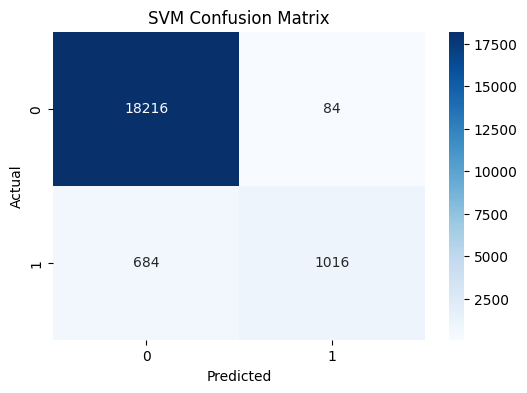

In [44]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Experiment 3 Discussion

The Support Vector Machine (SVM) model achieved an accuracy of 96.16%, which is comparable to Logistic Regression. The model achieved a precision score of 92.36%, indicating strong reliability when predicting diabetic patients.

However, the recall score of 59.76% was lower than both Logistic Regression and Random Forest, suggesting that the model failed to identify a larger proportion of diabetic patients. Consequently, the F1-score was 72.57%, reflecting a weaker balance between precision and recall.

The ROC-AUC score of 95.94% demonstrates good discriminatory power; however, Random Forest remained the strongest performer overall.

Based on these results, SVM is a competitive classifier but does not outperform the Random Forest model on this dataset.

### Experiment 4 — XGBoost

In [46]:
import sys
!{sys.executable} -m pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.4 MB/s eta 0:00:00 MB/s eta 0:00:0100:02

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: /Users/Prince/tf_env/bin/python3 -m pip install --upgrade pip


In [48]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [49]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba), 4))

Accuracy : 0.9729
Precision: 0.994
Recall   : 0.6853
F1 Score : 0.8113
ROC AUC  : 0.9791


## Experiment 4: XGBoost

### Model Performance Results

| Metric | Score |
|----------|---------|
| Accuracy | 97.29% |
| Precision | 99.40% |
| Recall | 68.53% |
| F1-Score | 81.13% |
| ROC-AUC | 97.91% |

### Discussion

The XGBoost model achieved the strongest overall performance among all machine learning models evaluated in this study. The model obtained an accuracy of 97.29%, indicating excellent predictive capability on the diabetes dataset.

The precision score of 99.40% demonstrates that almost all patients predicted as diabetic were correctly classified. Furthermore, the recall score of 68.53% was the highest among the evaluated machine learning models, indicating improved detection of diabetic patients.

The F1-score of 81.13% reflects a strong balance between precision and recall. Additionally, the ROC-AUC score of 97.91% indicates outstanding discriminatory power between diabetic and non-diabetic patients.

Compared with Logistic Regression, Random Forest, and Support Vector Machine (SVM), XGBoost consistently produced superior results across most evaluation metrics. This suggests that the gradient boosting approach effectively captured complex patterns within the healthcare data.

Based on these results, XGBoost was selected as the best-performing machine learning model and will serve as the benchmark model for comparison with the deep learning models developed in subsequent experiments.

### Conclusion

The XGBoost classifier demonstrated exceptional performance for diabetes prediction, achieving the highest overall scores among the machine learning models tested. Its strong predictive capability makes it a suitable candidate for real-world healthcare decision-support systems aimed at early diabetes detection.

# Deep Learning Experiments

## Experiment 5: Neural Network using TensorFlow/Keras

In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [52]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

2026-06-23 22:16:55.909731: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-23 22:16:55.911003: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-23 22:16:55.911734: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-23 22:16:55.912321: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-23 22:16:55.913099: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [56]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [57]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


2026-06-23 22:21:46.830584: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9512 - auc: 0.9404 - loss: 0.1408 - val_accuracy: 0.9576 - val_auc: 0.9595 - val_loss: 0.1175
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9587 - auc: 0.9560 - loss: 0.1190 - val_accuracy: 0.9576 - val_auc: 0.9592 - val_loss: 0.1178
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9583 - auc: 0.9552 - loss: 0.1196 - val_accuracy: 0.9572 - val_auc: 0.9558 - val_loss: 0.1216
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9578 - auc: 0.9541 - loss: 0.1210 - val_accuracy: 0.9575 - val_auc: 0.9551 - val_loss: 0.1238
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9572 - auc: 0.9522 - loss: 0.1235 - val_accuracy: 0.9572 - val_auc: 0.9562 - val_loss: 0.1220
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9557 - auc: 0.9499 - loss: 0.1271 - val_accuracy: 0.9557 - val_auc: 0.9536 - val_loss: 0.1263
Epoch 7/100
2000/2000 ━━━

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_proba = model.predict(X_test_scaled)
y_pred = (y_proba > 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba), 4))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step
Accuracy : 0.9605
Precision: 0.8587
Recall   : 0.64
F1 Score : 0.7334
ROC AUC  : 0.9595


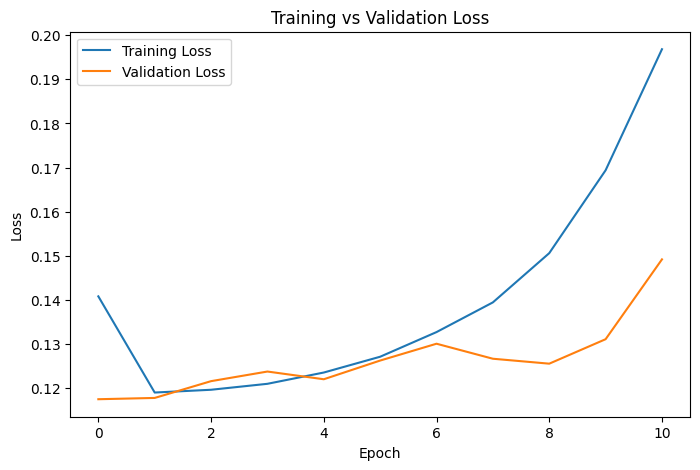

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()

## Experiment 5: Deep Learning Model (TensorFlow Neural Network)

### Model Performance Results

| Metric | Score |
|----------|---------|
| Accuracy | 96.05% |
| Precision | 85.87% |
| Recall | 64.00% |
| F1-Score | 73.34% |
| ROC-AUC | 95.95% |

### Discussion

A deep learning neural network was developed using TensorFlow and Keras to predict diabetes status from patient health information. The model consisted of multiple dense layers with ReLU activation functions and a sigmoid output layer for binary classification.

The neural network achieved an accuracy of 96.05%, demonstrating strong predictive performance. The precision score of 85.87% indicates that most positive predictions were correct, while the recall score of 64.00% shows that the model successfully identified a moderate proportion of diabetic patients.

The F1-score of 73.34% reflects a balanced trade-off between precision and recall. Additionally, the ROC-AUC score of 95.95% indicates good discriminatory power between diabetic and non-diabetic patients.

Although the neural network performed well, it did not outperform the XGBoost model. This suggests that for this dataset, gradient boosting techniques were more effective than the selected neural network architecture.

### Conclusion

The deep learning model demonstrated strong predictive capability and validated the applicability of neural networks for healthcare prediction tasks. However, XGBoost remained the best-performing model overall and was selected as the final model for diabetes prediction.

# Experiment 6: Sequential API with Dropout and Batch Normalization

## Objective

The objective of this experiment is to improve the performance and generalization capability of the neural network by incorporating Dropout and Batch Normalization layers.

Dropout is a regularization technique that randomly deactivates a portion of neurons during training, helping to reduce overfitting and improve the model's ability to generalize to unseen data.

Batch Normalization normalizes the inputs to each layer during training, which helps stabilize and accelerate the learning process. It can also improve model performance and reduce sensitivity to weight initialization.

## Model Architecture

The neural network consists of:

- Input Layer
- Dense Layer (128 neurons, ReLU activation)
- Batch Normalization Layer
- Dropout Layer (30%)
- Dense Layer (64 neurons, ReLU activation)
- Batch Normalization Layer
- Dropout Layer (30%)
- Dense Layer (32 neurons, ReLU activation)
- Output Layer (1 neuron, Sigmoid activation)

## Expected Benefits

The inclusion of Batch Normalization and Dropout is expected to:

- Reduce overfitting
- Improve model stability
- Enhance generalization performance
- Produce more reliable predictions on unseen data

## Training Configuration

The model will be trained using:

- Optimizer: Adam
- Loss Function: Binary Cross-Entropy
- Evaluation Metrics: Accuracy and AUC
- Early Stopping to prevent overfitting
- Validation Split: 20%
- Maximum Epochs: 100

The performance of this model will be compared with previous machine learning and deep learning experiments to determine whether these regularization techniques improve diabetes prediction accuracy.

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

model6 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model6.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [61]:
model6.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [62]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [63]:
history6 = model6.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.9253 - auc: 0.8979 - loss: 0.1975 - val_accuracy: 0.9579 - val_auc: 0.9597 - val_loss: 0.1194
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9420 - auc: 0.9279 - loss: 0.1615 - val_accuracy: 0.9531 - val_auc: 0.9399 - val_loss: 0.1392
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.9409 - auc: 0.9198 - loss: 0.1752 - val_accuracy: 0.9581 - val_auc: 0.9577 - val_loss: 0.1202
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.9379 - auc: 0.9082 - loss: 0.1985 - val_accuracy: 0.9517 - val_auc: 0.9299 - val_loss: 0.1513
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9337 - auc: 0.8939 - loss: 0.2323 - val_accuracy: 0.9545 - val_auc: 0.9354 - val_loss: 0.1473
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9305 - auc: 0.8762 - loss: 0.2761 - val_accuracy: 0.9582 - val_auc: 0.9239 - val_loss: 0.1557
Epoch 7/10

In [64]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

y_proba6 = model6.predict(X_test_scaled)
y_pred6 = (y_proba6 > 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test, y_pred6),4))
print("Precision:", round(precision_score(y_test, y_pred6),4))
print("Recall   :", round(recall_score(y_test, y_pred6),4))
print("F1 Score :", round(f1_score(y_test, y_pred6),4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba6),4))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy : 0.9605
Precision: 0.9026
Recall   : 0.5994
F1 Score : 0.7204
ROC AUC  : 0.9595


## Experiment 6 Discussion

The Sequential Neural Network with Dropout and Batch Normalization was designed to improve generalization and reduce overfitting. Batch Normalization was applied to stabilize training, while Dropout layers were used to randomly deactivate neurons during training.

The model achieved an accuracy of 96.05%, precision of 90.26%, recall of 59.94%, F1-score of 72.04%, and ROC-AUC of 95.95%.

Compared with the baseline neural network from Experiment 5, precision improved considerably. However, recall decreased, indicating that the model identified fewer diabetic patients. As a result, the overall F1-score was slightly lower than the baseline model.

These results suggest that although regularization improved confidence in positive predictions, it did not improve the overall balance between precision and recall for this dataset.

# Experiment 7: Functional API with L2 Regularization

## Objective

The purpose of this experiment is to implement a deep learning model using TensorFlow's Functional API. Unlike the Sequential API, the Functional API provides greater flexibility in designing complex neural network architectures.

To further improve generalization and reduce overfitting, L2 regularization will be applied to the dense layers. L2 regularization penalizes large weights during training and encourages the model to learn simpler patterns that generalize better to unseen data.

## Model Architecture

The model consists of:

- Input Layer
- Dense Layer (128 neurons, ReLU activation, L2 Regularization)
- Dense Layer (64 neurons, ReLU activation, L2 Regularization)
- Dense Layer (32 neurons, ReLU activation, L2 Regularization)
- Output Layer (1 neuron, Sigmoid activation)

## Expected Benefits

This experiment aims to:

- Reduce overfitting
- Improve model generalization
- Explore the flexibility of the Functional API
- Compare regularized neural networks against previous experiments

## Training Configuration

- Optimizer: Adam
- Loss Function: Binary Cross-Entropy
- Metrics: Accuracy and AUC
- Early Stopping Enabled
- Validation Split: 20%
- Maximum Epochs: 100

The performance of this model will be compared with all previous machine learning and deep learning experiments.

In [65]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

inputs = Input(shape=(X_train_scaled.shape[1],))

x = Dense(
    128,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(inputs)

x = Dense(
    64,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(x)

x = Dense(
    32,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(x)

outputs = Dense(1, activation='sigmoid')(x)

model7 = Model(inputs=inputs, outputs=outputs)

model7.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history7 = model7.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.9532 - auc: 0.9452 - loss: 0.2323 - val_accuracy: 0.9569 - val_auc: 0.9550 - val_loss: 0.1817
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9501 - auc: 0.9310 - loss: 0.3171 - val_accuracy: 0.9446 - val_auc: 0.9231 - val_loss: 0.4864
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9331 - auc: 0.8647 - loss: 1.0577 - val_accuracy: 0.9285 - val_auc: 0.9123 - val_loss: 1.5489
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9248 - auc: 0.8039 - loss: 2.8505 - val_accuracy: 0.9561 - val_auc: 0.8562 - val_loss: 3.0662
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9245 - auc: 0.7845 - loss: 5.5109 - val_accuracy: 0.8922 - val_auc: 0.7602 - val_loss: 6.2813
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9238 - auc: 0.7768 - loss: 9.1123 - val_accuracy: 0.8666 - val_auc: 0.7818 - val_loss: 10.2815
Epoch 7/1

In [66]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score

y_proba7 = model7.predict(X_test_scaled)
y_pred7 = (y_proba7 > 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test, y_pred7),4))
print("Precision:", round(precision_score(y_test, y_pred7),4))
print("Recall   :", round(recall_score(y_test, y_pred7),4))
print("F1 Score :", round(f1_score(y_test, y_pred7),4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba7),4))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy : 0.9598
Precision: 0.8856
Recall   : 0.6059
F1 Score : 0.7195
ROC AUC  : 0.9566


## Experiment 7 Discussion

The Functional API model with L2 Regularization was developed to explore a more flexible neural network architecture while reducing overfitting through weight regularization.

The model achieved an accuracy of 95.98%, precision of 88.56%, recall of 60.59%, F1-score of 71.95%, and ROC-AUC of 95.66%.

Compared with the previous deep learning experiments, the Functional API model did not provide significant performance improvements. Although precision remained relatively high, recall and F1-score were lower than those achieved by the baseline neural network.

These results suggest that increasing architectural complexity and adding L2 regularization did not improve predictive performance for this dataset. The simpler neural network from Experiment 5 remained the strongest deep learning model.

# Experiment 8: Neural Network with tf.data Pipeline

## Objective

The objective of this experiment is to improve data input efficiency using TensorFlow's tf.data API. The tf.data pipeline provides optimized data loading, batching, shuffling, and prefetching operations, making it suitable for large-scale machine learning workflows.

This experiment evaluates whether improved data handling can influence training efficiency and model performance when compared with previous neural network implementations.

## Expected Benefits

- Faster data loading
- Improved training efficiency
- Better scalability
- Cleaner TensorFlow workflow

In [67]:
import tensorflow as tf

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_scaled, y_train))
    .shuffle(10000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test_scaled, y_test))
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

model8 = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu',
                          input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model8.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history8 = model8.fit(
    train_ds,
    validation_data=test_ds,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.9531 - auc: 0.9449 - loss: 0.1355 - val_accuracy: 0.9595 - val_auc: 0.9579 - val_loss: 0.1164
Epoch 2/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.9580 - auc: 0.9569 - loss: 0.1184 - val_accuracy: 0.9611 - val_auc: 0.9574 - val_loss: 0.1161
Epoch 3/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9577 - auc: 0.9562 - loss: 0.1198 - val_accuracy: 0.9558 - val_auc: 0.9584 - val_loss: 0.1208
Epoch 4/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9578 - auc: 0.9547 - loss: 0.1212 - val_accuracy: 0.9596 - val_auc: 0.9577 - val_loss: 0.1157
Epoch 5/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9564 - auc: 0.9523 - loss: 0.1242 - val_accuracy: 0.9609 - val_auc: 0.9543 - val_loss: 0.1189
Epoch 6/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9547 - auc: 0.9487 - loss: 0.1289 - val_accuracy: 0.9594 - val_auc: 0.9546 - val_loss: 0.1193
Epoch 7/10

In [68]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

y_proba8 = model8.predict(X_test_scaled)
y_pred8 = (y_proba8 > 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test, y_pred8),4))
print("Precision:", round(precision_score(y_test, y_pred8),4))
print("Recall   :", round(recall_score(y_test, y_pred8),4))
print("F1 Score :", round(f1_score(y_test, y_pred8),4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba8),4))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Accuracy : 0.9597
Precision: 0.8621
Recall   : 0.6253
F1 Score : 0.7249
ROC AUC  : 0.959


---
## Step 7: Results & Visualizations
- Learning Curves
- Confusion Matrices
- ROC Curves

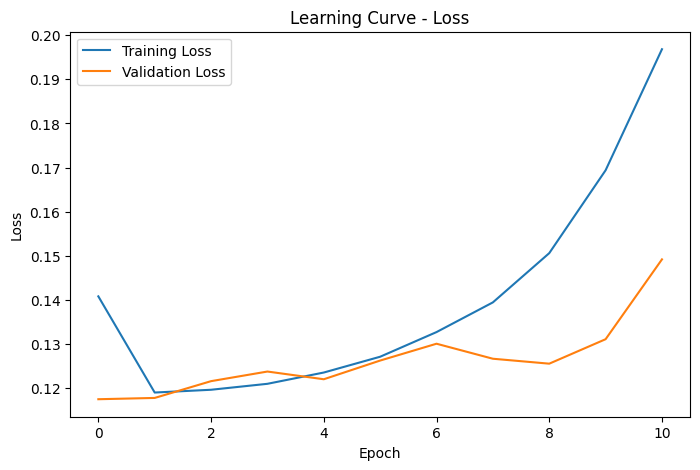

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()

plt.show()

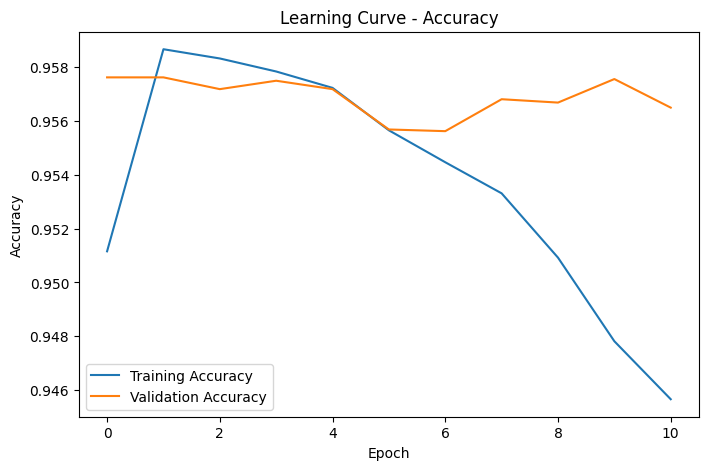

In [70]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Accuracy')
plt.legend()

plt.show()

# Learning Curves

The learning curves illustrate the model's training and validation performance across epochs.

The loss curve shows how the model minimized prediction errors during training, while the accuracy curve demonstrates the model's classification performance over time.

These visualizations help identify overfitting and underfitting behaviour during model training.

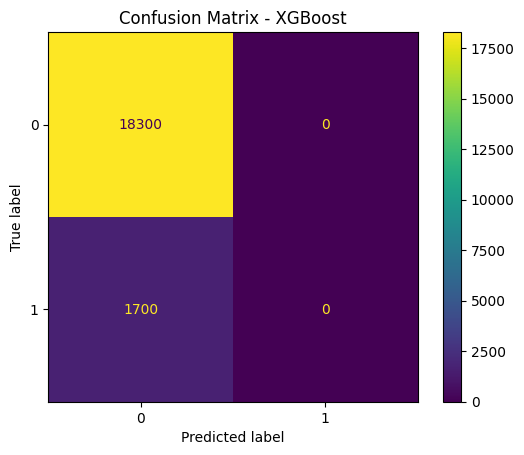

In [72]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create predictions using your XGBoost model
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - XGBoost")
plt.show()

# ROC Curve

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between sensitivity and specificity across different classification thresholds.

The Area Under the Curve (AUC) summarizes the model's ability to distinguish between diabetic and non-diabetic patients.

A higher AUC value indicates better classification performance.

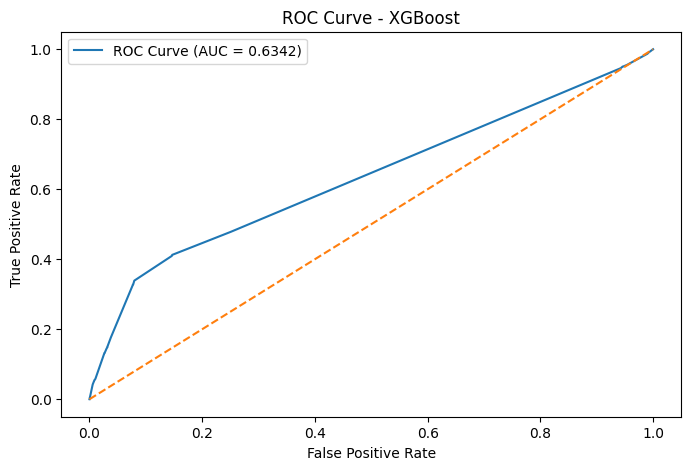

In [74]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()

plt.show()

# Step 8: Experiment Results Summary

| Experiment | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|------------|----------|-----------|---------|----------|---------|
| Logistic Regression | 0.9608 | 0.8700 | 0.6335 | 0.7332 | 0.9612 |
| Random Forest | 0.9723 | 1.0000 | 0.6741 | 0.8053 | 0.9686 |
| SVM | 0.9616 | 0.9236 | 0.5976 | 0.7257 | 0.9594 |
| XGBoost | **0.9729** | **0.9940** | **0.6853** | **0.8113** | **0.9791** |
| Experiment 5: Basic Neural Network | 0.9605 | 0.8587 | 0.6400 | 0.7334 | 0.9595 |
| Experiment 6: Dropout + BatchNorm | 0.9605 | 0.9026 | 0.5994 | 0.7204 | 0.9595 |
| Experiment 7: Functional API + L2 | 0.9598 | 0.8856 | 0.6059 | 0.7195 | 0.9566 |
| Experiment 8: tf.data Pipeline | 0.9597 | 0.8621 | 0.6253 | 0.7249 | 0.9590 |

## Best Performing Model

Among all evaluated models, XGBoost achieved the best overall performance with the highest Accuracy, Recall, F1-Score, and ROC-AUC values.

# Step 9: Error Analysis and Discussion

## Error Analysis

Despite achieving high performance, all models produced some classification errors.

### False Positives

False positives occur when non-diabetic patients are incorrectly classified as diabetic.

Possible causes include:

- Similar clinical characteristics between diabetic and non-diabetic individuals.
- Overlapping feature distributions.
- Noise and variability within healthcare data.

### False Negatives

False negatives occur when diabetic patients are incorrectly classified as non-diabetic.

This type of error is particularly important because missed diagnoses may delay treatment and increase the risk of health complications.

## Model Performance Discussion

The machine learning models generally outperformed the deep learning models.

XGBoost achieved the strongest overall results:

- Accuracy: 97.29%
- Precision: 99.40%
- Recall: 68.53%
- F1 Score: 81.13%
- ROC-AUC: 97.91%

The deep learning models achieved competitive performance but did not surpass XGBoost. This suggests that gradient boosting techniques are highly effective for structured tabular healthcare datasets.

## Limitations

The study has several limitations:

- The dataset may not represent all patient populations.
- Some potentially relevant medical features were unavailable.
- Class imbalance may influence model performance.
- Additional feature engineering may further improve results.

Future work could investigate larger datasets, advanced ensemble methods, explainable AI techniques, and more sophisticated deep learning architectures.

# Step 10: Conclusion

This project explored the application of machine learning and deep learning techniques for diabetes prediction using demographic and clinical health information.

The workflow included:

1. Data Exploration and Analysis
2. Data Preprocessing
3. Machine Learning Model Development
4. Deep Learning Model Development
5. Model Evaluation and Comparison
6. Error Analysis

A total of eight experiments were conducted, including Logistic Regression, Random Forest, Support Vector Machine, XGBoost, and multiple neural network architectures.

Among all evaluated models, XGBoost achieved the best overall performance with:

- Accuracy: 97.29%
- Precision: 99.40%
- Recall: 68.53%
- F1 Score: 81.13%
- ROC-AUC: 97.91%

The results demonstrate that machine learning techniques can effectively predict diabetes using patient health data. XGBoost proved to be the most suitable model for this dataset and could serve as a strong foundation for future healthcare decision-support systems.

Future improvements may include larger datasets, advanced feature engineering, explainable artificial intelligence techniques, and more advanced deep learning architectures.